# EDA & Data Preparation

Dataset: **UVFD dermatoscopy hair-removal** (Mendeley: https://data.mendeley.com/datasets/wvmw7p76t8/1)

[Kaggle: https://www.kaggle.com/datasets/samirhossain2001/automatic-hair-removal]

## 1. Setup & imports

In [1]:
from __future__ import annotations
import os, re, glob, json, random, warnings
from collections import Counter, defaultdict
from typing import Callable

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch, torchvision

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations"], check=True)
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
for name, mod in [("numpy", np), ("torch", torch), ("torchvision", torchvision), ("albumentations", A)]:
    print(f"{name:14}: {mod.__version__}")

numpy         : 2.0.2
torch         : 2.10.0+cu128
torchvision   : 0.25.0+cu128
albumentations: 2.0.8


## 2. CONFIG

In [2]:
def find_data_root() -> str:
    candidates = [
        "/kaggle/input/datasets/samirhossain2001/automatic-hair-removal/Dataset",
        "e:/CSE438_DIP/CSE438_Assignment/Dataset",
    ]
    candidates += [os.path.dirname(p) for p in glob.glob("/kaggle/input/**/black_masks", recursive=True)]
    for root in candidates:
        if root and all(os.path.isdir(os.path.join(root, d)) for d in ("images", "black_masks", "white_masks")):
            return root
    raise FileNotFoundError("No folder with images/ black_masks/ white_masks/ found.")

DATA_ROOT = find_data_root()
CONFIG = {
    "DATA_ROOT":   DATA_ROOT,
    "IMAGES_DIR":  os.path.join(DATA_ROOT, "images"),
    "BLACK_DIR":   os.path.join(DATA_ROOT, "black_masks"),
    "WHITE_DIR":   os.path.join(DATA_ROOT, "white_masks"),
    "OUT_DIR":     "/kaggle/working" if os.path.isdir("/kaggle/working") else ".",
    "SEED":        42,
    "IMG_SIZE":    512,
    "NUM_CLASSES": 3,
    "CLASS_NAMES": {0: "background", 1: "dark_hair_ruler", 2: "light_hair_uv"},
    "CLASS_COLORS": {1: (255, 0, 0), 2: (0, 255, 0)},
    "MASK_THRESH": 127,
    "SPLIT_RATIO": (0.70, 0.15, 0.15),
}
for k, v in CONFIG.items():
    print(f"{k:12}: {v}")

DATA_ROOT   : /kaggle/input/datasets/samirhossain2001/automatic-hair-removal/Dataset
IMAGES_DIR  : /kaggle/input/datasets/samirhossain2001/automatic-hair-removal/Dataset/images
BLACK_DIR   : /kaggle/input/datasets/samirhossain2001/automatic-hair-removal/Dataset/black_masks
WHITE_DIR   : /kaggle/input/datasets/samirhossain2001/automatic-hair-removal/Dataset/white_masks
OUT_DIR     : /kaggle/working
SEED        : 42
IMG_SIZE    : 512
NUM_CLASSES : 3
CLASS_NAMES : {0: 'background', 1: 'dark_hair_ruler', 2: 'light_hair_uv'}
CLASS_COLORS: {1: (255, 0, 0), 2: (0, 255, 0)}
MASK_THRESH : 127
SPLIT_RATIO : (0.7, 0.15, 0.15)


## 3. Shared utilities

In [3]:
def set_seed(seed: int = CONFIG["SEED"]) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def group_key(filename: str) -> str:
    stem = filename[:-4] if filename.lower().endswith(".png") else filename
    stem = re.sub(r"^crop_\d+_", "", stem)     
    stem = re.sub(r"_crop_\d+$", "", stem)     
    return stem

def load_gray_mask(path: str, size: int) -> np.ndarray:
    m = Image.open(path).convert("L").resize((size, size), Image.NEAREST)
    return np.asarray(m) > CONFIG["MASK_THRESH"]

def build_label(filename: str, size: int | None = None) -> np.ndarray:
    size = size or CONFIG["IMG_SIZE"]
    label = np.zeros((size, size), np.uint8)
    if filename in BLACK_MASKS:
        label[load_gray_mask(os.path.join(CONFIG["BLACK_DIR"], filename), size)] = 1
    if filename in WHITE_MASKS:
        label[load_gray_mask(os.path.join(CONFIG["WHITE_DIR"], filename), size)] = 2
    return label

def overlay(image: np.ndarray, label: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    out = image.astype(np.float32).copy()
    for cls, colour in CONFIG["CLASS_COLORS"].items():
        m = label == cls
        for c in range(3):
            out[..., c][m] = (1 - alpha) * out[..., c][m] + alpha * colour[c]
    return out.astype(np.uint8)

def load_rgb(filename: str, size: int | None = None) -> np.ndarray:
    size = size or CONFIG["IMG_SIZE"]
    return np.asarray(Image.open(os.path.join(CONFIG["IMAGES_DIR"], filename)).convert("RGB").resize((size, size)))

def show_overlay_grid(filenames, title: str, images=None, labels=None, ncols: int | None = None):
    n = len(filenames if images is None else images)
    ncols = ncols or n
    fig, ax = plt.subplots(2, ncols, figsize=(2.7 * ncols, 5.6))
    ax = np.atleast_2d(ax)
    for i in range(ncols):
        img = load_rgb(filenames[i]) if images is None else images[i]
        lab = build_label(filenames[i]) if labels is None else labels[i]
        cap = (filenames[i][:18] if filenames is not None else "")
        ax[0, i].imshow(img);                 ax[0, i].set_title(cap, fontsize=7)
        ax[1, i].imshow(overlay(img, lab))
        for r in range(2): ax[r, i].axis("off")
    ax[0, 0].set_ylabel("image", fontsize=9); ax[1, 0].set_ylabel("overlay", fontsize=9)
    fig.suptitle(title + "   (red = dark hair/ruler, green = light hair/UV)", y=1.02)
    fig.tight_layout(); plt.show()

set_seed()
BLACK_MASKS = set(os.listdir(CONFIG["BLACK_DIR"]))
IMAGE_FILES = sorted(os.listdir(CONFIG["IMAGES_DIR"]))
WHITE_MASKS = {f for f in os.listdir(CONFIG["WHITE_DIR"]) if f in set(IMAGE_FILES)} 
print(f"images: {len(IMAGE_FILES)} | dark masks: {len(BLACK_MASKS)} | light masks: {len(WHITE_MASKS)}")
print("group_key examples:",
      group_key("crop_10_p23_field1.png"), "|", group_key("image00005_crop_004.png"))

images: 2653 | dark masks: 2097 | light masks: 849
group_key examples: p23_field1 | image00005


---
## 4. Exploratory Data Analysis

### File inventory

In [4]:
imgs, black, white = set(IMAGE_FILES), set(os.listdir(CONFIG["BLACK_DIR"])), set(os.listdir(CONFIG["WHITE_DIR"]))
both = imgs & black & white
inventory = pd.Series({
    "images": len(imgs), "dark_masks": len(black),
    "light_masks (folder)": len(white), "light_masks (usable)": len(WHITE_MASKS),
    "have both": len(both), "images with no mask": len(imgs - black - white),
})
print(inventory.to_string())

images                  2653
dark_masks              2097
light_masks (folder)     850
light_masks (usable)     849
have both                293
images with no mask        0


### Image size & aspect-ratio distribution

distinct sizes: {(512, 512): 2653}


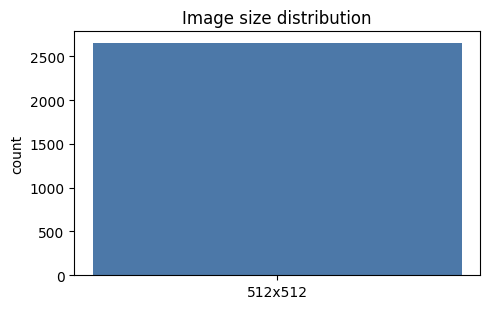

In [5]:
sizes = Counter()
for fn in IMAGE_FILES:
    with Image.open(os.path.join(CONFIG["IMAGES_DIR"], fn)) as im:
        sizes[im.size] += 1
print("distinct sizes:", dict(sizes))
plt.figure(figsize=(5, 3.2))
plt.bar([f"{w}x{h}" for w, h in sizes], list(sizes.values()), color="#4C78A8")
plt.title("Image size distribution"); plt.ylabel("count"); plt.tight_layout(); plt.show()

### Label builder sanity check

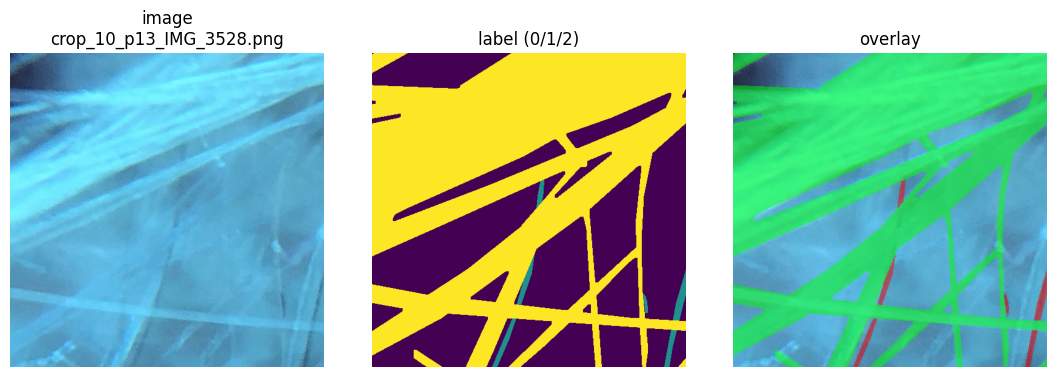

unique label values: [0 1 2]


In [6]:
demo = next(f for f in IMAGE_FILES if f in BLACK_MASKS and f in WHITE_MASKS)
img, lab = load_rgb(demo), build_label(demo)
fig, ax = plt.subplots(1, 3, figsize=(11, 3.7))
ax[0].imshow(img);                                   ax[0].set_title(f"image\n{demo[:26]}")
ax[1].imshow(lab, cmap="viridis", vmin=0, vmax=2);   ax[1].set_title("label (0/1/2)")
ax[2].imshow(overlay(img, lab));                     ax[2].set_title("overlay")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("unique label values:", np.unique(lab))

### Pixel-level class distribution

          class    pixels  pixel_fraction  images_containing
     background 669052621         0.96202               2653
dark_hair_ruler  18112425         0.02604               2095
  light_hair_uv   8302986         0.01194                849


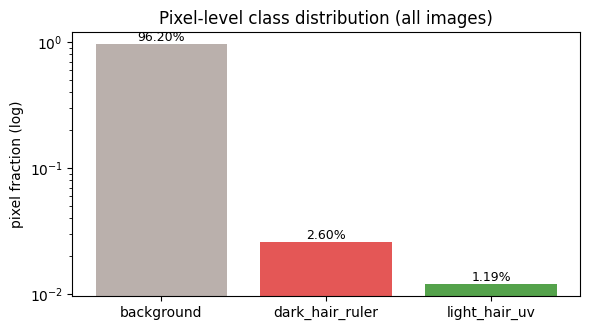

In [7]:
def pixel_histogram(files: list[str]) -> tuple[np.ndarray, np.ndarray]:
    pixel_counts = np.zeros(CONFIG["NUM_CLASSES"], np.int64)
    images_with = np.zeros(CONFIG["NUM_CLASSES"], np.int64)
    for fn in files:
        counts = np.bincount(build_label(fn).ravel(), minlength=CONFIG["NUM_CLASSES"])
        pixel_counts += counts
        images_with += counts > 0
    return pixel_counts, images_with

names = [CONFIG["CLASS_NAMES"][k] for k in range(CONFIG["NUM_CLASSES"])]
pixel_counts, images_with = pixel_histogram(IMAGE_FILES)
frac = pixel_counts / pixel_counts.sum()

dist = pd.DataFrame({"class": names, "pixels": pixel_counts,
                     "pixel_fraction": np.round(frac, 5), "images_containing": images_with})
print(dist.to_string(index=False))

plt.figure(figsize=(6, 3.4))
plt.bar(names, frac, color=["#BAB0AC", "#E45756", "#54A24B"])
plt.yscale("log"); plt.ylabel("pixel fraction (log)"); plt.title("Pixel-level class distribution (all images)")
for k in range(CONFIG["NUM_CLASSES"]):
    plt.text(k, frac[k], f"{frac[k] * 100:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

### Representative image mask pairs for every class

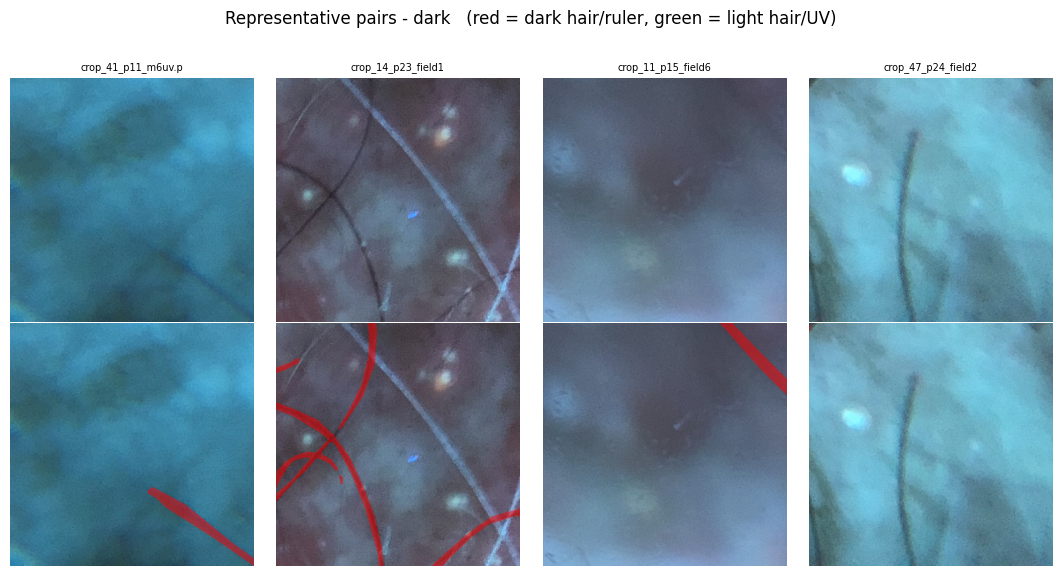

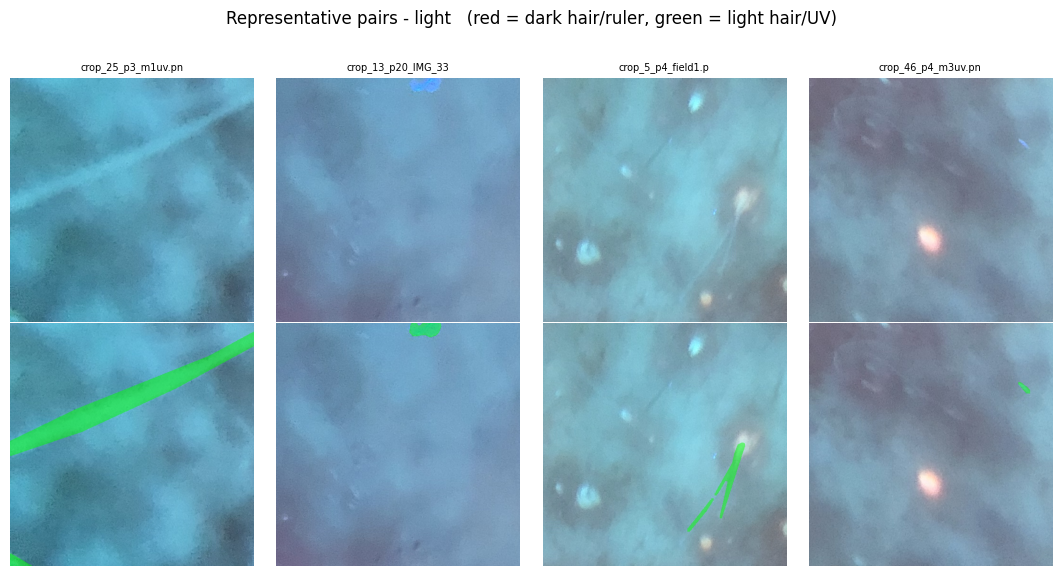

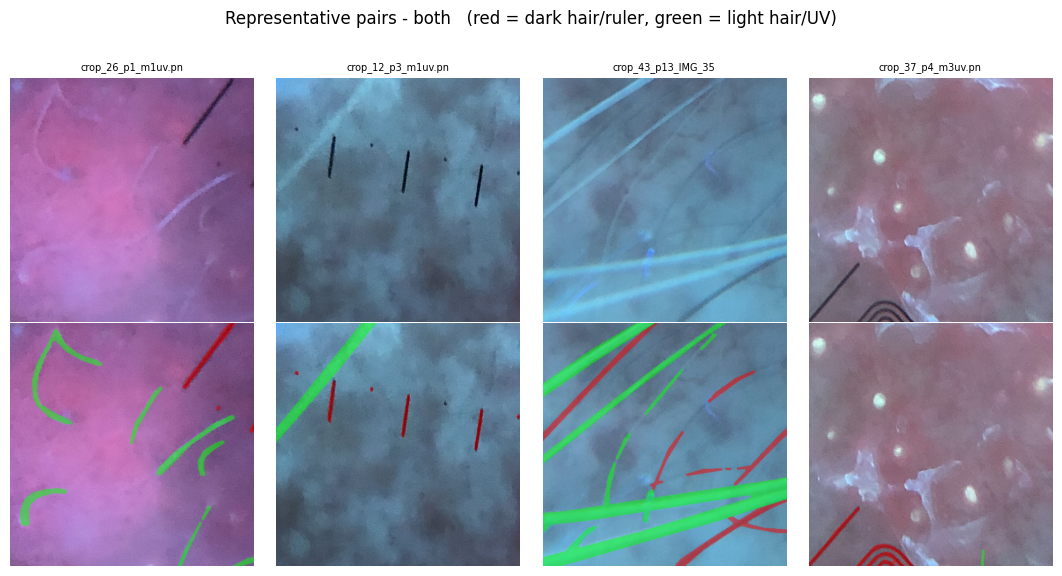

In [8]:
def sample_class(kind: str, n: int = 4) -> list[str]:
    if kind == "dark":    pool = [f for f in IMAGE_FILES if f in BLACK_MASKS and f not in WHITE_MASKS]
    elif kind == "light": pool = [f for f in IMAGE_FILES if f in WHITE_MASKS and f not in BLACK_MASKS]
    else:                 pool = [f for f in IMAGE_FILES if f in BLACK_MASKS and f in WHITE_MASKS]
    set_seed(); return random.sample(pool, min(n, len(pool)))

for kind in ("dark", "light", "both"):
    show_overlay_grid(sample_class(kind), title=f"Representative pairs - {kind}")

### Corruption & image mask mismatch checks

In [9]:
def scan_folder(folder: str) -> tuple[int, int]:
    bad_open = bad_size = 0
    for fn in os.listdir(folder):
        path = os.path.join(folder, fn)
        try:
            with Image.open(path) as im: im.verify()
            with Image.open(path) as im:
                bad_size += im.size != (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])
        except Exception:
            bad_open += 1
    return bad_open, bad_size

report = {name: scan_folder(CONFIG[key]) for name, key in
          [("images", "IMAGES_DIR"), ("dark_masks", "BLACK_DIR"), ("light_masks", "WHITE_DIR")]}
print(pd.DataFrame(report, index=["corrupted", "wrong_size"]).T.to_string())

             corrupted  wrong_size
images               0           0
dark_masks           0           0
light_masks          0           0


---
## 5. Leakage-safe train/val/test split

In [10]:
def make_grouped_split(files: list[str], seed: int, ratio: tuple[float, float, float]) -> dict[str, list[str]]:
    groups: dict[str, list[str]] = defaultdict(list)
    for f in files: groups[group_key(f)].append(f)

    sized = [(g, len(m)) for g, m in groups.items()]
    random.Random(seed).shuffle(sized)
    total = len(files)
    target = dict(zip(("train", "val", "test"), (r * total for r in ratio)))
    filled = {"train": 0, "val": 0, "test": 0}
    assign: dict[str, str] = {}
    for g, size in sorted(sized, key=lambda gs: -gs[1]):
        sp = max(target, key=lambda k: target[k] - filled[k]); assign[g] = sp; filled[sp] += size

    split = {"train": [], "val": [], "test": []}
    for g in sorted(groups):
        split[assign[g]].extend(sorted(groups[g]))
    split["_assign"] = assign
    return split

split = make_grouped_split(IMAGE_FILES, CONFIG["SEED"], CONFIG["SPLIT_RATIO"])
assign = split.pop("_assign")

image_to_split = {f: sp for sp, files in split.items() for f in files}
assert len(image_to_split) == len(IMAGE_FILES), "image counted in multiple splits!"
groups = defaultdict(list)
for f in IMAGE_FILES: groups[group_key(f)].append(f)
for g, members in groups.items():
    assert len({image_to_split[f] for f in members}) == 1, f"group {g} spans splits"

summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "groups": [sum(v == s for v in assign.values()) for s in ("train", "val", "test")],
    "images": [len(split[s]) for s in ("train", "val", "test")],
    "fraction": [round(len(split[s]) / len(IMAGE_FILES), 3) for s in ("train", "val", "test")],
})
print(summary.to_string(index=False))
print(f"\ngroups: {len(groups)}")

split  groups  images  fraction
train      66    1859     0.701
  val      28     399     0.150
 test      27     395     0.149

groups: 121


### Class weights from the TRAIN split only

In [11]:
train_counts, _ = pixel_histogram(split["train"])
train_frac = train_counts / train_counts.sum()
inverse_freq = 1.0 / train_frac; inverse_freq /= inverse_freq.sum() / CONFIG["NUM_CLASSES"]  # mean = 1
median_freq = np.median(train_frac) / train_frac

weights_table = pd.DataFrame({
    "class": names,
    "train_fraction": np.round(train_frac, 5),
    "full_fraction": np.round(frac, 5),
    "inverse_freq_w": np.round(inverse_freq, 3),
    "median_freq_w": np.round(median_freq, 3),
})
print(weights_table.to_string(index=False))

          class  train_fraction  full_fraction  inverse_freq_w  median_freq_w
     background         0.96109        0.96202           0.029          0.025
dark_hair_ruler         0.02359        0.02604           1.170          1.000
  light_hair_uv         0.01532        0.01194           1.801          1.540


### Save shared artifacts

In [12]:
def dump_json(obj, name: str) -> str:
    path = os.path.join(CONFIG["OUT_DIR"], name)
    with open(path, "w") as f: json.dump(obj, f, indent=2)
    return path

class_names_str = {str(k): v for k, v in CONFIG["CLASS_NAMES"].items()}
paths = [
    dump_json({"seed": CONFIG["SEED"], "ratio": list(CONFIG["SPLIT_RATIO"]),
               "group_unit": "source_photograph", "num_groups": len(groups),
               "num_classes": CONFIG["NUM_CLASSES"], "class_names": class_names_str,
               "group_assignment": assign, **{k: split[k] for k in ("train", "val", "test")}},
              "split.json"),
    dump_json({"source": "train_split", "train_fraction": train_frac.tolist(),
               "full_fraction": frac.tolist(), "inverse_freq": inverse_freq.tolist(),
               "median_freq": median_freq.tolist(), "class_names": class_names_str},
              "class_weights.json"),
]
results_path = os.path.join(CONFIG["OUT_DIR"], "results.json")
if not os.path.exists(results_path): dump_json({"models": {}}, "results.json")
print("saved:", [os.path.basename(p) for p in paths] + ["results.json"], "->", CONFIG["OUT_DIR"])

saved: ['split.json', 'class_weights.json', 'results.json'] -> /kaggle/working


---
## 6. Data augmentation

In [13]:
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

def build_transforms(img_size: int) -> tuple[A.Compose, A.Compose]:
    """Return (train_tf, eval_tf). train_tf augments; eval_tf only normalizes."""
    train_tf = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.05), rotate=(-20, 20), mode=0, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),   
        A.OneOf([A.CLAHE(clip_limit=2.0), A.RandomGamma(gamma_limit=(80, 120))], p=0.2),  
        A.ElasticTransform(alpha=1.0, sigma=50.0, p=0.15),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])
    eval_tf = A.Compose([A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])
    return train_tf, eval_tf

train_tf, eval_tf = build_transforms(CONFIG["IMG_SIZE"])
print("TRAIN pipeline:")
for t in train_tf.transforms: print(f"  {t.__class__.__name__:24} p={getattr(t, 'p', 1.0)}")
print("EVAL pipeline :", [t.__class__.__name__ for t in eval_tf.transforms])

TRAIN pipeline:
  HorizontalFlip           p=0.5
  VerticalFlip             p=0.5
  RandomRotate90           p=0.5
  Affine                   p=0.3
  RandomBrightnessContrast p=0.3
  OneOf                    p=0.2
  ElasticTransform         p=0.15
  Normalize                p=1.0
  ToTensorV2               p=1.0
EVAL pipeline : ['Normalize', 'ToTensorV2']


### Augmentation showcase

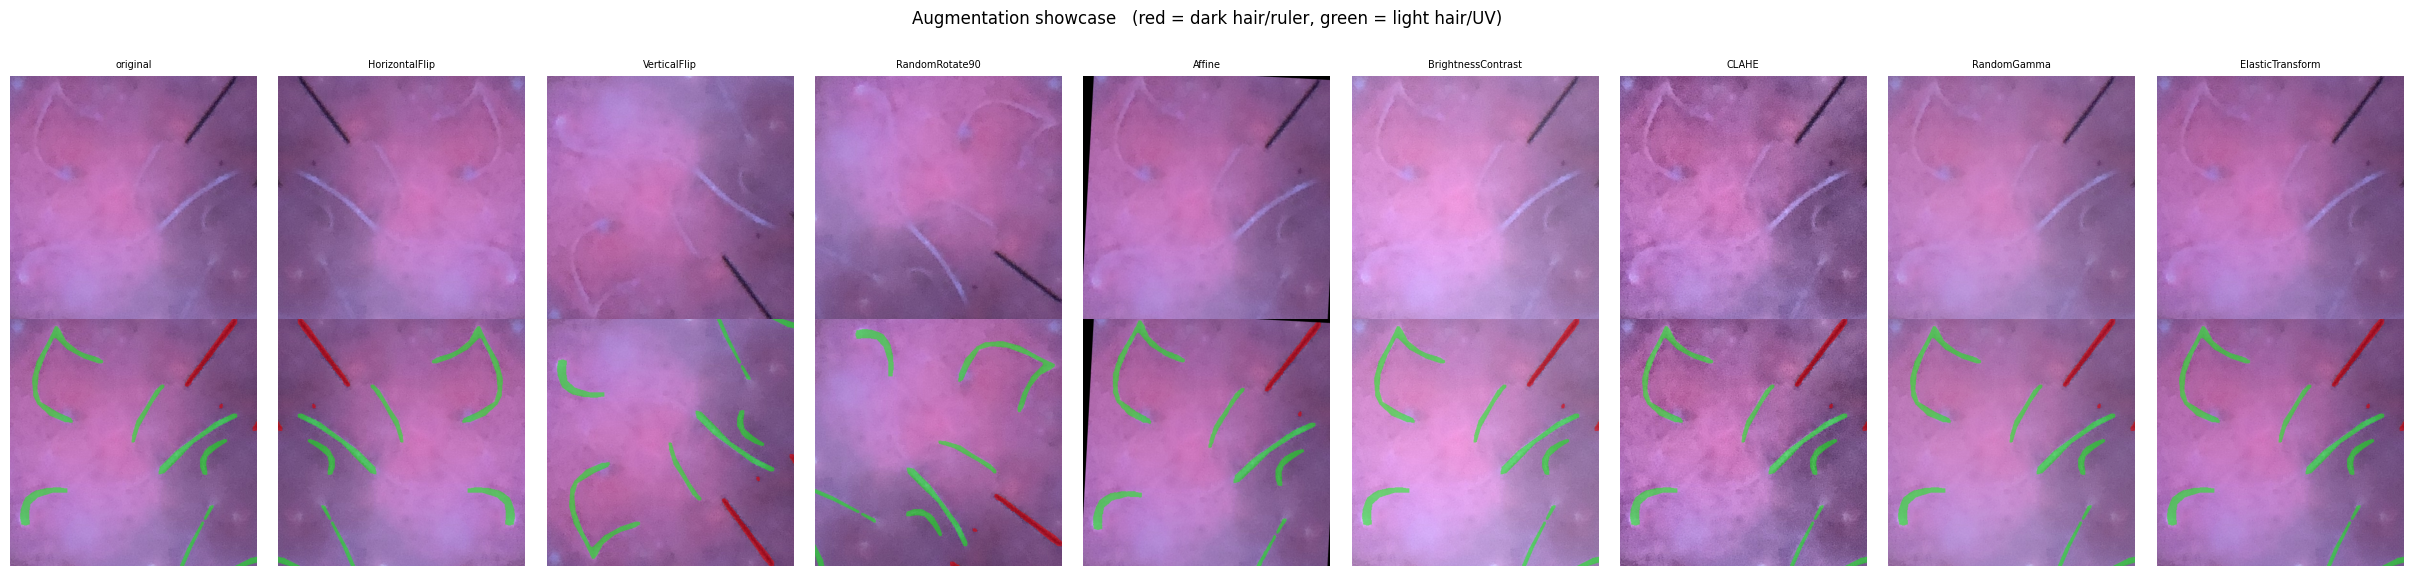

In [14]:
def build_showcase(filename: str):
    img, mask = load_rgb(filename), build_label(filename)
    single = [
        ("original",           None),
        ("HorizontalFlip",     A.HorizontalFlip(p=1.0)),
        ("VerticalFlip",       A.VerticalFlip(p=1.0)),
        ("RandomRotate90",     A.RandomRotate90(p=1.0)),
        ("Affine",             A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.05), rotate=(-20, 20), mode=0, p=1.0)),
        ("BrightnessContrast", A.RandomBrightnessContrast(0.2, 0.2, p=1.0)),
        ("CLAHE",              A.CLAHE(clip_limit=2.0, p=1.0)),
        ("RandomGamma",        A.RandomGamma((80, 120), p=1.0)),
        ("ElasticTransform",   A.ElasticTransform(alpha=1.0, sigma=50.0, p=1.0)),
    ]
    titles, images, masks = [], [], []
    for name, tf in single:
        out = {"image": img, "mask": mask} if tf is None else A.Compose([tf])(image=img, mask=mask)
        titles.append(name); images.append(out["image"]); masks.append(out["mask"])
    return titles, images, masks

set_seed()
titles, images, masks = build_showcase(sample_class("both", n=1)[0])
show_overlay_grid(titles, title="Augmentation showcase", images=images, labels=masks, ncols=len(titles))

---
## Sanity-check visualization

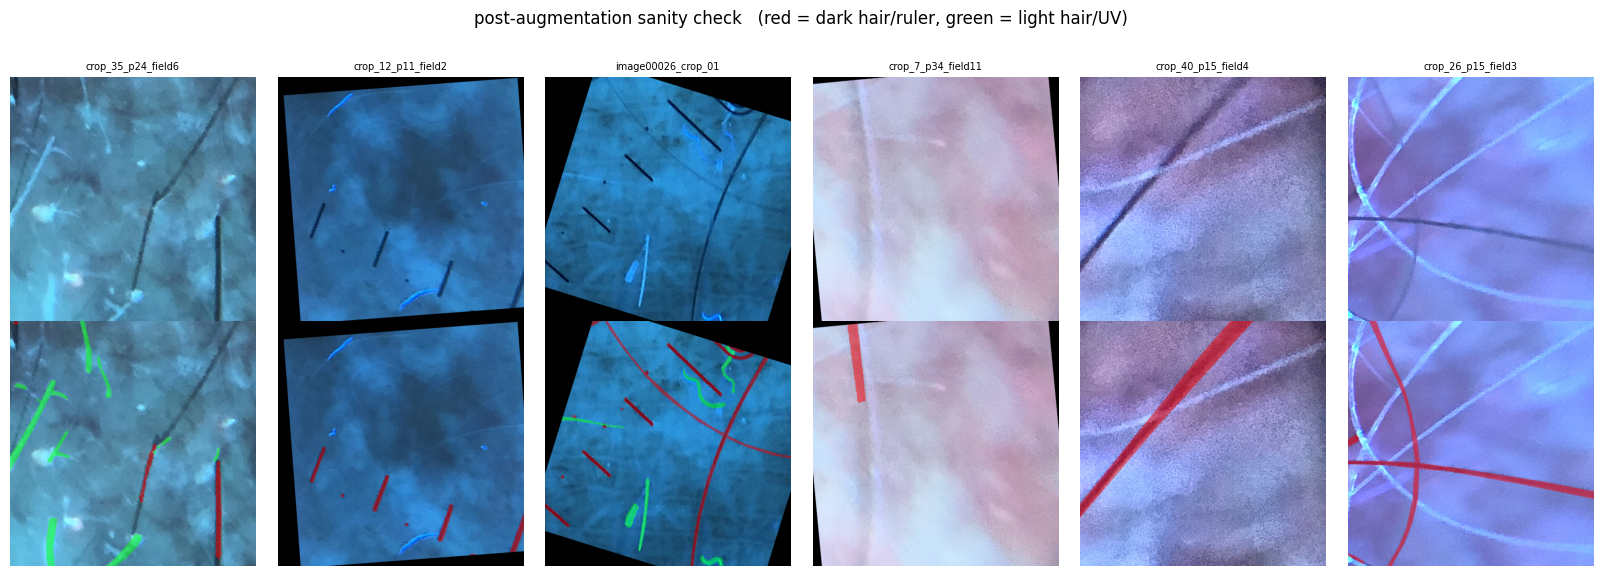

In [15]:
class SegDataset(torch.utils.data.Dataset):
    def __init__(self, files: list[str], transform: A.Compose):
        self.files, self.transform = files, transform
    def __len__(self) -> int:
        return len(self.files)
    def __getitem__(self, i: int):
        fn = self.files[i]
        out = self.transform(image=load_rgb(fn), mask=build_label(fn))
        return out["image"], out["mask"].long(), fn

def denormalize(image_tensor: torch.Tensor) -> np.ndarray:
    x = image_tensor.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return (np.clip(x, 0, 1) * 255).astype(np.uint8)

set_seed()
train_ds = SegDataset(split["train"], train_tf)
samples = [train_ds[i] for i in random.sample(range(len(train_ds)), 6)]
show_overlay_grid(
    filenames=[fn for *_, fn in samples],
    title="post-augmentation sanity check",
    images=[denormalize(img) for img, _, _ in samples],
    labels=[mask.numpy() for _, mask, _ in samples],
    ncols=6,
)